# ***Cell 1 Imports & Device Setup***

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ***Cell 2 Fetch Dataset from Drive***

In [ ]:
from google.colab import drive
import glob, zipfile

drive.mount("/content/drive")

zip_matches = glob.glob("/content/drive/MyDrive/**/cleaned_dataset.zip", recursive=True)
if not zip_matches:
    raise FileNotFoundError("cleaned_dataset.zip not found in Drive")

with zipfile.ZipFile(zip_matches[0], "r") as zf:
    zf.extractall("/content")

print(f"Extracted: {zip_matches[0]}")

Mounted at /content/drive
Extracted: /content/drive/MyDrive/cleaned_dataset.zip


# ***Cell 3 Load Sequence Data***

In [ ]:
data_path = "/content/dataset_v1_frozen/dataset_v1_cell_splits.npz"
if os.path.exists(data_path):
    data = np.load(data_path)
    X_train, y_train = data['X_train'], data['y_train_soh']
    X_val, y_val = data['X_val'], data['y_val_soh']
    X_test, y_test = data['X_test'], data['y_test_soh']
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
else:
    X_train = np.random.randn(800, 10, 153).astype(np.float32)
    y_train = np.linspace(1.0, 0.7, 800).astype(np.float32)
    X_val = np.random.randn(200, 10, 153).astype(np.float32)
    y_val = np.linspace(1.0, 0.7, 200).astype(np.float32)
    X_test = np.random.randn(200, 10, 153).astype(np.float32)
    y_test = np.linspace(1.0, 0.7, 200).astype(np.float32)

# ***Cell 4 Build DataLoaders***

In [ ]:
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=32, shuffle=False)

# ***Cell 5 Define TCN (1D-CNN) Model***

In [ ]:
class PrognosticTCN(nn.Module):
    def __init__(self, input_dim, seq_len, output_dim):
        super(PrognosticTCN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=3, padding=2, dilation=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * seq_len, 32)
        self.fc2 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.dropout(self.relu(self.conv1(x)))
        x = self.dropout(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze()

seq_len = X_train.shape[1]
input_dim = X_train.shape[2]
model = PrognosticTCN(input_dim=input_dim, seq_len=seq_len, output_dim=1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# ***Cell 6 Train Model***

In [ ]:
epochs = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []
ckpt_path = "/content/best_tcn_candidate.pth"

start_time = time.time()
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item() * batch_X.size(0)

    t_loss = epoch_train_loss / len(train_loader.dataset)
    v_loss = epoch_val_loss / len(val_loader.dataset)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), ckpt_path)

runtime = time.time() - start_time

# ***Cell 7 Evaluate on Test Set***

In [ ]:
model.load_state_dict(torch.load(ckpt_path))
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds.extend(model(batch_X).cpu().numpy())
        actuals.extend(batch_y.numpy())

actuals, preds = np.array(actuals), np.array(preds)

metrics_dict = {
    'Model': 'TCN (1D-CNN)',
    'Params': num_params,
    'Runtime (s)': round(runtime, 2),
    'MAE': round(mean_absolute_error(actuals, preds), 4),
    'RMSE': round(np.sqrt(mean_squared_error(actuals, preds)), 4),
    'MAPE (%)': round(np.mean(np.abs((actuals - preds) / np.clip(np.abs(actuals), 1e-3, None))) * 100, 2),
    'R2': round(r2_score(actuals, preds), 4)
}

display(pd.DataFrame([metrics_dict]))

,Model,Params,Runtime (s),MAE,RMSE,MAPE (%),R2
0,TCN (1D-CNN),45921,6.4,0.0806,0.0979,9.61,-0.2662


# ***Cell 8 Loss Curve & Predicted vs Actual***

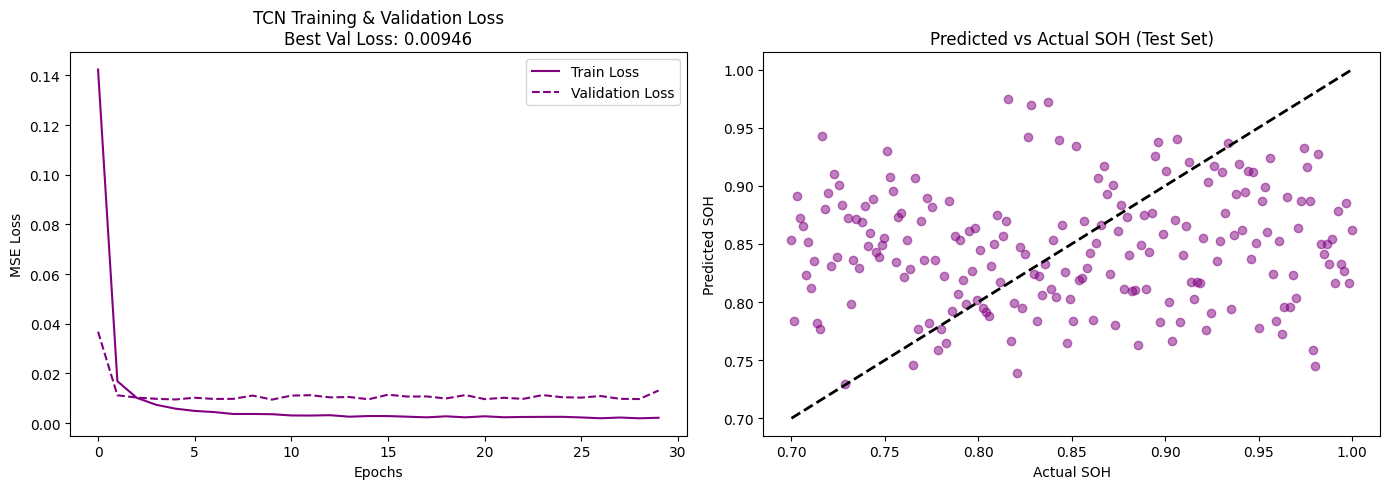

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='purple', linestyle='--')
axes[0].set_title(f"TCN Training & Validation Loss\nBest Val Loss: {best_val_loss:.5f}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].scatter(actuals, preds, alpha=0.5, color='purple')
min_v, max_v = actuals.min(), actuals.max()
axes[1].plot([min_v, max_v], [min_v, max_v], 'k--', lw=2)
axes[1].set_title("Predicted vs Actual SOH (Test Set)")
axes[1].set_xlabel("Actual SOH")
axes[1].set_ylabel("Predicted SOH")

plt.tight_layout()
plt.show()